Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Le modèle Poids Lourd
from xgboost import XGBClassifier

# Tuning et Évaluation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

Chargement des données et gestion du déséquilibre

In [3]:
PATH = '/kaggle/input/notebooks/yasminabouziane/data-rainprediction/' 

print("Chargement des données en cours...")
X_train = pd.read_csv(PATH + 'X_train.csv')
X_test = pd.read_csv(PATH + 'X_test.csv')
y_train = pd.read_csv(PATH + 'y_train.csv').values.ravel()
y_test = pd.read_csv(PATH + 'y_test.csv').values.ravel()

# Calcul du poids pour gérer le déséquilibre (Majorité / Minorité)
jours_sans_pluie = np.sum(y_train == 0)
jours_avec_pluie = np.sum(y_train == 1)
poids_desequilibre = jours_sans_pluie / jours_avec_pluie

print(f"Ratio pour scale_pos_weight : {poids_desequilibre:.2f}")

Chargement des données en cours...
Ratio pour scale_pos_weight : 3.46


Entraînement et Tuning (RandomizedSearchCV)

In [4]:
# 1. Initialisation du modèle
xgb = XGBClassifier(
    scale_pos_weight=poids_desequilibre, 
    random_state=42, 
    eval_metric='auc', # On lui dit de surveiller l'AUC
    n_jobs=-1          # Utilise tous les cœurs du processeur
)

# 2. Grille des paramètres à tester
param_distributions = {
    'max_depth': [3, 5, 7, 9],               # Profondeur des arbres
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Vitesse d'apprentissage
    'n_estimators': [100, 200, 300],         # Nombre d'arbres
    'subsample': [0.8, 1.0],                 # Pourcentage de données utilisées par arbre (évite le sur-apprentissage)
    'colsample_bytree': [0.8, 1.0]           # Pourcentage de colonnes utilisées par arbre
}

# 3. Configuration de la recherche aléatoire
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=15,          # Nombre de combinaisons à tester 
    scoring='roc_auc',  # Optimisation de l'aire sous la courbe
    cv=3,               # Validation croisée à 3 plis pour aller plus vite
    random_state=42,
    verbose=2,
    n_jobs=-1
)

print("Lancement de l'entraînement et du tuning XGBoost (patience...)...")
random_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres trouvés : {random_search.best_params_}")

Lancement de l'entraînement et du tuning XGBoost (patience...)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Meilleurs paramètres trouvés : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


Évaluation rigoureuse et Courbe ROC

--- RAPPORT DE CLASSIFICATION XGBOOST ---
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     22064
           1       0.58      0.79      0.67      6375

    accuracy                           0.82     28439
   macro avg       0.76      0.81      0.77     28439
weighted avg       0.85      0.82      0.83     28439



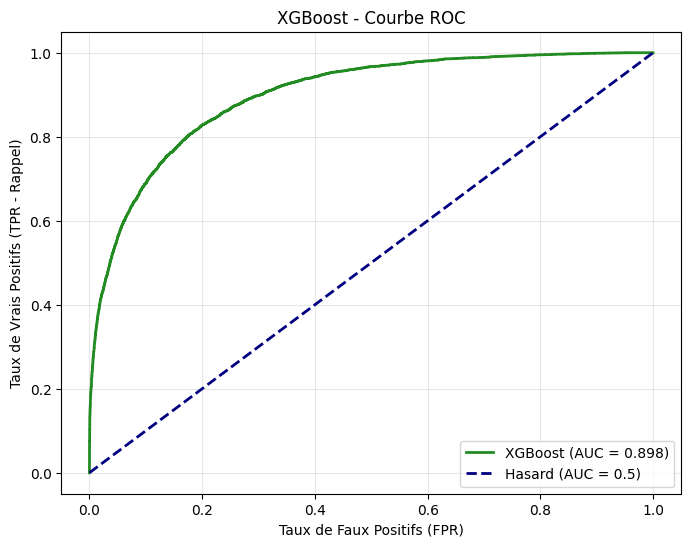

In [5]:
# On récupère le meilleur modèle XGBoost
best_xgb = random_search.best_estimator_

# Prédictions
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# 1. Rapport de classification
print("--- RAPPORT DE CLASSIFICATION XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

# 2. Courbe ROC et AUC
auc_score_xgb = roc_auc_score(y_test, y_proba_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='forestgreen', lw=2, label=f'XGBoost (AUC = {auc_score_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR - Rappel)')
plt.title('XGBoost - Courbe ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Interprétabilité

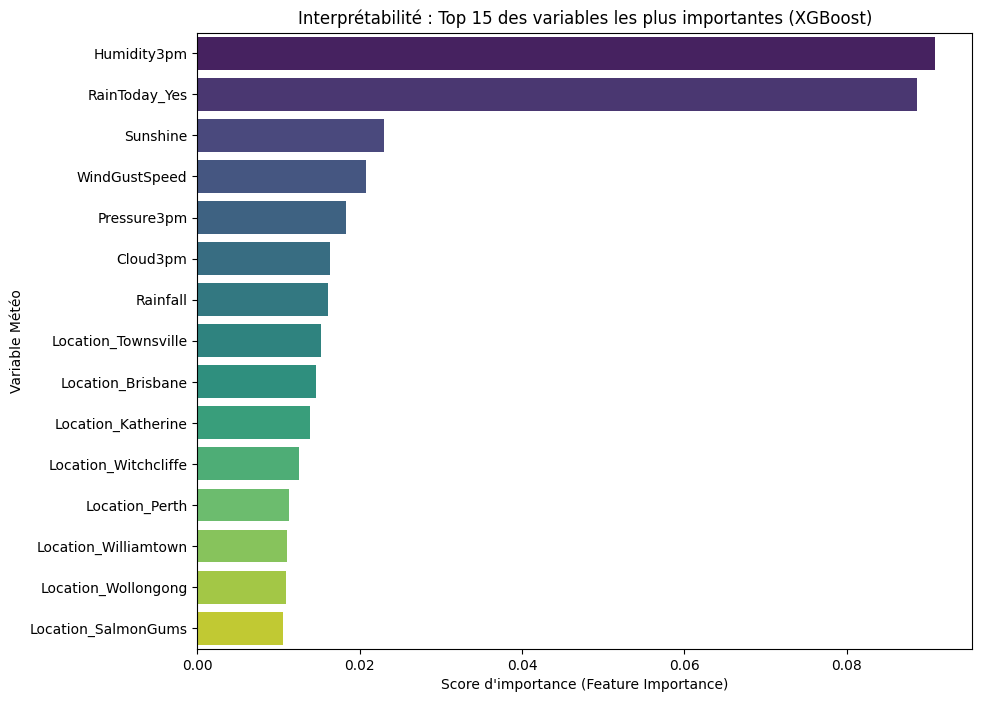


Analyse :
XGBoost identifie naturellement les 'splits' (coupures) les plus efficaces.
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=9, n_estimators=200, subsample=1.0; total time=  12.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=300, subsample=0.8; total time=  12.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, n_estimators=300, subsample=1.0; total time=  16.3s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=200, subsample=1.0; total time=   6.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=200, subsample=1.0; total time=   6.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=1.0; total time=  11.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=  15.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=1.0; total 

In [7]:
# Récupération de l'importance des variables
importances = best_xgb.feature_importances_
features = X_train.columns

# Création d'un DataFrame
df_importance = pd.DataFrame({'Variable': features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(15)

# Visualisation
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')
plt.title("Interprétabilité : Top 15 des variables les plus importantes (XGBoost)")
plt.xlabel("Score d'importance (Feature Importance)")
plt.ylabel('Variable Météo')
plt.show()

print("\nAnalyse :")
print("XGBoost identifie naturellement les 'splits' (coupures) les plus efficaces.")
